# Bayesian Decision Network for Heart Disease Diagnosis

**Course project — Decision Making under Uncertainty**

---

## Overview

This notebook models the clinical decision of whether to conduct further diagnostic testing for a patient, given observed physiological indicators. The core framework is a **Bayesian Decision Network (BDN)**, which combines probabilistic reasoning with decision theory to derive the action that maximises expected utility.

The analysis proceeds through five stages:

1. **Data acquisition and exploration** — load the Heart Disease UCI dataset and inspect its structure.
2. **Preprocessing** — discretise continuous variables into clinically interpretable bins.
3. **Network specification** — define the Directed Acyclic Graph (DAG), factor algebra, and utility table.
4. **Inference and optimisation** — compute the Maximum Expected Utility (MEU) and the optimal policy, both unconditionally and conditioned on specific patient evidence.
5. **Value of information** — calculate the Expected Value of Perfect Information (EVPI) and visualise posterior disease probabilities.


---

## 1. Data Acquisition


In [1]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

file_path = "HeartDiseaseTrain-Test.csv"

df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "ketangangal/heart-disease-dataset-uci",
    file_path,
)

/tmp/ipykernel_12087/2799785701.py:6: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


100%|██████████| 111k/111k [00:00<00:00, 210kB/s]


The dataset contains 1,025 patient records sourced from the UCI Heart Disease repository. Each record includes demographic features (age, sex), clinical measurements (cholesterol, resting blood pressure, maximum heart rate), and a binary target indicating the presence of heart disease.


In [2]:
df.describe()

,age,resting_blood_pressure,cholestoral,Max_heart_rate,oldpeak,target
count,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000
mean,54.434146,131.611707,246.00000,149.114146,1.071512,0.513171
std,9.072290,17.516718,51.59251,23.005724,1.175053,0.500070
min,29.000000,94.000000,126.00000,71.000000,0.000000,0.000000
25%,48.000000,120.000000,211.00000,132.000000,0.000000,0.000000
50%,56.000000,130.000000,240.00000,152.000000,0.800000,1.000000
75%,61.000000,140.000000,275.00000,166.000000,1.800000,1.000000
max,77.000000,200.000000,564.00000,202.000000,6.200000,1.000000


---

## 2. Dependencies


In [3]:
import pandas as pd
import numpy as np
import copy
import matplotlib.pyplot as plt
import warnings
import networkx as nx

warnings.filterwarnings('ignore')

---

## 3. Network Specification

### 3.1 Variable Index

Each node in the network is assigned an integer identifier used internally by the factor algebra:

| ID | Symbol | Role | Description |
|----|--------|------|-------------|
| 0  | D      | Random   | Disease (binary: 0 = no, 1 = yes) |
| 1  | C      | Random   | Cholesterol level (3 bins) |
| 2  | E      | Random   | Exercise-induced angina (binary) |
| 3  | A      | Random   | Age group (3 bins) |
| 4  | H      | Random   | Maximum heart rate (3 bins) |
| 5  | S      | Decision | Decision to test or not test |

### 3.2 Causal Structure

The DAG encodes the following assumptions:

- **Age (A)** is a root cause that influences cholesterol levels, maximum heart rate, and the likelihood of exercise-induced angina.
- **Cholesterol (C)**, **Heart rate (H)**, and **Exercise-induced angina (E)** each independently contribute to the probability of **Disease (D)**.
- The **Utility** node is jointly determined by the disease outcome and the clinician's decision.


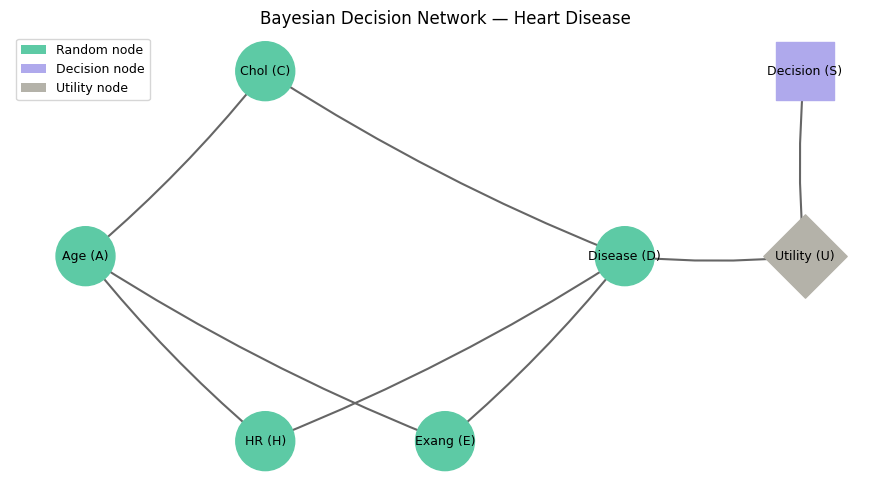

In [4]:
def draw_dag():
    G = nx.DiGraph()
    nodes = {
        "Age (A)":      {"type": "random"},
        "Chol (C)":     {"type": "random"},
        "HR (H)":       {"type": "random"},
        "Exang (E)":    {"type": "random"},
        "Disease (D)":  {"type": "random"},
        "Decision (S)": {"type": "decision"},
        "Utility (U)":  {"type": "utility"},
    }
    edges = [
        ("Age (A)",     "Chol (C)"),
        ("Age (A)",     "HR (H)"),
        ("Age (A)",     "Exang (E)"),
        ("Chol (C)",    "Disease (D)"),
        ("HR (H)",      "Disease (D)"),
        ("Exang (E)",   "Disease (D)"),
        ("Disease (D)", "Utility (U)"),
        ("Decision (S)","Utility (U)"),
    ]
    G.add_nodes_from(nodes.keys())
    G.add_edges_from(edges)

    pos = {
        "Age (A)":      (0, 1),
        "Chol (C)":     (1, 2),
        "HR (H)":       (1, 0),
        "Exang (E)":    (2, 0),
        "Disease (D)":  (3, 1),
        "Decision (S)": (4, 2),
        "Utility (U)":  (4, 1),
    }

    fig, ax = plt.subplots(figsize=(9, 5))
    color_map = {
        "random":   "#5DCAA5",
        "decision": "#AFA9EC",
        "utility":  "#B4B2A9",
    }
    shapes = {"random": "o", "decision": "s", "utility": "D"}

    for ntype, shape in shapes.items():
        ns = [n for n in G.nodes() if nodes[n]["type"] == ntype]
        nc = [color_map[ntype]] * len(ns)
        nx.draw_networkx_nodes(G, pos, nodelist=ns, node_shape=shape,
                               node_color=nc, node_size=1800, ax=ax)

    nx.draw_networkx_labels(G, pos, font_size=9, font_weight="500", ax=ax)
    nx.draw_networkx_edges(G, pos, arrows=True, arrowsize=20,
                           edge_color="#666", width=1.5,
                           connectionstyle="arc3,rad=0.05", ax=ax)

    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor="#5DCAA5", label="Random node"),
        Patch(facecolor="#AFA9EC", label="Decision node"),
        Patch(facecolor="#B4B2A9", label="Utility node"),
    ]
    ax.legend(handles=legend_elements, loc="upper left", fontsize=9)
    ax.set_title("Bayesian Decision Network — Heart Disease", fontsize=12)
    ax.axis("off")
    plt.tight_layout()
    plt.savefig("dag_heart.png", dpi=150, bbox_inches="tight")
    plt.show()

draw_dag()

---

## 4. Factor Algebra

A **factor** $\phi(X_1, X_2, \ldots, X_n)$ maps every joint assignment of its variables to a non-negative real number. In probabilistic graphical models, factors represent Conditional Probability Tables (CPTs) and Utility Tables.

Each factor is stored as a dictionary with three fields:

| Field  | Description |
|--------|-------------|
| `var`  | List of variable IDs involved in the factor |
| `card` | Cardinality of each variable (number of states) |
| `val`  | Flattened 1-D array of factor values |

The flattening convention follows row-major (last index changes fastest) ordering. The functions `idx_to_assign` and `assign_to_idx` convert between flat indices and variable assignments, enabling efficient lookup and computation across factors.

### 4.1 Factor Construction and Indexing


In [5]:
def make_factor(variables, cardinalities, values=None):
    """Initialise a factor with given variables and cardinalities."""
    size = int(np.prod(cardinalities))
    val = np.zeros(size) if values is None else np.array(values, dtype=float)
    return {
        "var":  list(variables),
        "card": list(cardinalities),
        "val":  val
    }

def idx_to_assign(idx, cards):
    """Convert a flat index to a variable assignment list."""
    assign = []
    for c in reversed(cards):
        assign.append(idx % c)
        idx //= c
    return list(reversed(assign))

def assign_to_idx(assign, cards):
    """Convert a variable assignment list to a flat index."""
    idx = 0
    stride = 1
    for i in range(len(assign) - 1, -1, -1):
        idx += assign[i] * stride
        stride *= cards[i]
    return idx

### 4.2 Core Factor Operations

Three operations form the backbone of exact inference in graphical models:

- **Factor product** — combines two factors over their union of variables, analogous to pointwise multiplication of joint distributions.
- **Factor marginalisation** — sums out a variable from a factor, reducing its scope.
- **Observation** — conditions a factor on an observed value by zeroing out inconsistent entries.


In [6]:
def factor_product(A, B):
    """Compute the factor product of A and B over their union of variables."""
    if not A["var"]: return B
    if not B["var"]: return A

    all_vars = list(dict.fromkeys(A["var"] + B["var"]))
    card_map  = {v: c for v, c in zip(A["var"], A["card"])}
    card_map.update({v: c for v, c in zip(B["var"], B["card"])})
    all_cards = [card_map[v] for v in all_vars]

    C = make_factor(all_vars, all_cards)
    for i in range(len(C["val"])):
        assignment = idx_to_assign(i, all_cards)
        amap = {v: assignment[j] for j, v in enumerate(all_vars)}
        ia = assign_to_idx([amap[v] for v in A["var"]], A["card"])
        ib = assign_to_idx([amap[v] for v in B["var"]], B["card"])
        C["val"][i] = A["val"][ia] * B["val"][ib]
    return C

def factor_sum(A, B):
    """Elementwise sum of two factors with identical scope."""
    C = copy.deepcopy(A)
    C["val"] = A["val"] + B["val"]
    return C

def factor_marginalize(F, var):
    """Sum out variable `var` from factor F."""
    if var not in F["var"]:
        return F
    idx       = F["var"].index(var)
    new_vars  = [v for v in F["var"]  if v != var]
    new_cards = [c for i, c in enumerate(F["card"]) if i != idx]
    G = make_factor(new_vars, new_cards if new_cards else [1])
    for i in range(len(F["val"])):
        assignment     = idx_to_assign(i, F["card"])
        new_assignment = [assignment[j] for j in range(len(assignment)) if j != idx]
        gi = assign_to_idx(new_assignment, new_cards) if new_cards else 0
        G["val"][gi] += F["val"][i]
    return G

def observe(F, var, val):
    """Condition factor F on the event var = val."""
    if var not in F["var"]:
        return F
    G   = copy.deepcopy(F)
    idx = G["var"].index(var)
    for i in range(len(G["val"])):
        assignment = idx_to_assign(i, G["card"])
        if assignment[idx] != val:
            G["val"][i] = 0
    return G

def normalize_factor(F):
    """Normalise factor values to sum to 1."""
    s = F["val"].sum()
    G = copy.deepcopy(F)
    if s > 0:
        G["val"] = G["val"] / s
    return G

### 4.3 Decision-Theoretic Queries

The following functions operate over the full influence diagram to compute expected utilities and optimal policies.

- `calculate_euf`: Builds the **Expected Utility Factor** by combining all random factors with the utility table and marginalising out all non-decision variables.
- `optimize_meu`: Selects the decision that maximises expected utility.
- `optimize_meu_evidence`: Applies evidence first, then optimises — used for patient-specific decisions.
- `query_disease`: Computes the posterior marginal $P(D \mid \text{evidence})$.


In [7]:
def calculate_euf(I):
    """Compute the Expected Utility Factor by marginalising all non-decision variables."""
    joint = None
    for rf in I["RandomFactors"]:
        joint = rf if joint is None else factor_product(joint, rf)

    euf = factor_product(joint, I["UtilityFactors"][0])

    decision_vars = set()
    for d in I["DecisionFactors"]:
        decision_vars.update(d["var"])

    for v in list(euf["var"]):
        if v not in decision_vars:
            euf = factor_marginalize(euf, v)
    return euf


def optimize_meu(I):
    """Return the MEU and the optimal deterministic policy."""
    D   = I["DecisionFactors"][0]
    euf = calculate_euf(I)

    opt = copy.deepcopy(D)
    opt["val"] = np.zeros(len(D["val"]))
    best = np.argmax(euf["val"])
    opt["val"][best] = 1
    return euf["val"][best], opt


def optimize_meu_evidence(I, evidence):
    """Condition the influence diagram on evidence, then compute MEU."""
    I2 = copy.deepcopy(I)
    for v, val in evidence.items():
        I2["RandomFactors"] = [observe(f, v, val) for f in I2["RandomFactors"]]
    return optimize_meu(I2)


def query_disease(I, evidence):
    """Compute the posterior marginal P(D | evidence)."""
    factors = [copy.deepcopy(f) for f in I["RandomFactors"]]
    for v, val in evidence.items():
        factors = [observe(f, v, val) for f in factors]
    joint = factors[0]
    for f in factors[1:]:
        joint = factor_product(joint, f)
    for v in [1, 2, 3, 4]:
        joint = factor_marginalize(joint, v)
    return normalize_factor(joint)


def evpi(I):
    """
    Compute the Expected Value of Perfect Information.

    EVPI = MEU(perfect info) - MEU(no info)

    This measures the maximum a decision-maker should be willing to pay
    to learn the true disease state before acting.
    """
    meu_base,    _ = optimize_meu(I)
    D_factor       = query_disease(I, evidence={})
    p_no_disease   = D_factor["val"][0]
    p_disease      = D_factor["val"][1]

    U = I["UtilityFactors"][0]
    eu_if_know_no  = max(U["val"][assign_to_idx([0, 0], [2, 2])],
                         U["val"][assign_to_idx([0, 1], [2, 2])])
    eu_if_know_yes = max(U["val"][assign_to_idx([1, 0], [2, 2])],
                         U["val"][assign_to_idx([1, 1], [2, 2])])

    meu_perfect = p_no_disease * eu_if_know_no + p_disease * eu_if_know_yes
    return max(0, meu_perfect - meu_base)

---

## 5. Data Preprocessing

Continuous variables are discretised into clinically motivated bins before being used to estimate CPTs from data. Laplace smoothing ($\varepsilon = 10^{-3}$) is applied throughout to avoid zero probabilities in sparsely populated cells.

| Variable | Bins | Labels |
|----------|------|--------|
| Age | (0, 40], (40, 55], (55, 100] | 0, 1, 2 |
| Cholesterol | (0, 200], (200, 240], (240, +∞) | 0, 1, 2 |
| Max heart rate | (0, 120], (120, 160], (160, +∞) | 0, 1, 2 |
| Exercise-induced angina | No / Yes | 0, 1 |


In [8]:
def discretize(df):
    df = df.copy()
    df["age_bin"]  = pd.cut(df["age"],          [0, 40, 55, 100],  labels=[0, 1, 2]).astype(int)
    df["chol_bin"] = pd.cut(df["cholestoral"],   [0, 200, 240, 1000], labels=[0, 1, 2]).astype(int)
    df["hr_bin"]   = pd.cut(df["Max_heart_rate"], [0, 120, 160, 250], labels=[0, 1, 2]).astype(int)
    df["exang_bin"] = (df["exercise_induced_angina"] == "Yes").astype(int)
    df["target"]    = df["target"].astype(int)
    return df

df = discretize(df)
df.head()

,age,sex,chest_pain_type,resting_blood_pressure,cholestoral,fasting_blood_sugar,rest_ecg,Max_heart_rate,exercise_induced_angina,oldpeak,slope,vessels_colored_by_flourosopy,thalassemia,target,age_bin,chol_bin,hr_bin,exang_bin
0,52,Male,Typical angina,125,212,Lower than 120 mg/ml,ST-T wave abnormality,168,No,1.0,Downsloping,Two,Reversable Defect,0,1,1,2,0
1,53,Male,Typical angina,140,203,Greater than 120 mg/ml,Normal,155,Yes,3.1,Upsloping,Zero,Reversable Defect,0,1,1,1,1
2,70,Male,Typical angina,145,174,Lower than 120 mg/ml,ST-T wave abnormality,125,Yes,2.6,Upsloping,Zero,Reversable Defect,0,2,0,1,1
3,61,Male,Typical angina,148,203,Lower than 120 mg/ml,ST-T wave abnormality,161,No,0.0,Downsloping,One,Reversable Defect,0,2,1,2,0
4,62,Female,Typical angina,138,294,Greater than 120 mg/ml,ST-T wave abnormality,106,No,1.9,Flat,Three,Fixed Defect,0,2,2,0,0


---

## 6. Parameter Estimation (CPT Learning)

Each Conditional Probability Table is estimated empirically from the data using frequency counts with Laplace smoothing. The structure follows the DAG defined in Section 3.


In [9]:
# P(A): marginal distribution of age group
A = make_factor([3], [3])
counts    = df["age_bin"].value_counts().sort_index()
A["val"]  = (counts.values + 1e-3) / (counts.values + 1e-3).sum()

# P(C | A): cholesterol conditioned on age
C = make_factor([1, 3], [3, 3])
for a in range(3):
    sub   = df[df["age_bin"] == a]
    total = len(sub) + 3 * 1e-3
    for c in range(3):
        count = (sub["chol_bin"] == c).sum() + 1e-3
        C["val"][assign_to_idx([c, a], [3, 3])] = count / total

# P(H | C): heart rate conditioned on cholesterol
H = make_factor([4, 1], [3, 3])
for c in range(3):
    sub   = df[df["chol_bin"] == c]
    total = len(sub) + 3 * 1e-3
    for h in range(3):
        count = (sub["hr_bin"] == h).sum() + 1e-3
        H["val"][assign_to_idx([h, c], [3, 3])] = count / total

# P(E | A): exercise angina conditioned on age
E = make_factor([2, 3], [2, 3])
for a in range(3):
    sub   = df[df["age_bin"] == a]
    total = len(sub) + 2 * 1e-3
    for e in range(2):
        count = (sub["exang_bin"] == e).sum() + 1e-3
        E["val"][assign_to_idx([e, a], [2, 3])] = count / total

# P(D | C, H, E): disease conditioned on cholesterol, heart rate, and angina
D = make_factor([0, 1, 4, 2], [2, 3, 3, 2])
eps = 1e-3
for c in range(3):
    for h in range(3):
        for e in range(2):
            sub   = df[(df["chol_bin"] == c) & (df["hr_bin"] == h) & (df["exang_bin"] == e)]
            total = len(sub) + 2 * eps
            p1    = (sub["target"].sum() + eps) / total
            p0    = 1 - p1
            D["val"][assign_to_idx([0, c, h, e], [2, 3, 3, 2])] = p0
            D["val"][assign_to_idx([1, c, h, e], [2, 3, 3, 2])] = p1

---

## 7. Utility Table and Influence Diagram Assembly

The utility function $U(D, S)$ encodes the payoff for each combination of disease outcome and decision. The values below reflect a scenario where failing to test a diseased patient carries the highest cost, while unnecessarily ordering a test for a healthy patient has a moderate cost.

| Disease (D) | Decision (S) | Utility |
|-------------|--------------|---------|
| 0 (no disease) | 0 (no test) | +10 |
| 0 (no disease) | 1 (test)    | −20 |
| 1 (disease)    | 0 (no test) | −100 |
| 1 (disease)    | 1 (test)    | +80 |

The influence diagram $\mathcal{I}$ is assembled from random factors (CPTs), the decision factor, and the utility factor.


In [10]:
# Decision factor — uniform prior over actions
S = make_factor([5], [2], [0.5, 0.5])

# Utility table U(D, S)
U = make_factor([0, 5], [2, 2])
U["val"][assign_to_idx([0, 0], [2, 2])] =   10   # no disease, no test
U["val"][assign_to_idx([0, 1], [2, 2])] =  -20   # no disease, test
U["val"][assign_to_idx([1, 0], [2, 2])] = -100   # disease, no test
U["val"][assign_to_idx([1, 1], [2, 2])] =   80   # disease, test

# Assemble the influence diagram
I = {
    "RandomFactors":   [A, C, H, E, D],
    "DecisionFactors": [S],
    "UtilityFactors":  [U]
}

---

## 8. Optimisation and Inference

### 8.1 Unconditional MEU

We first compute the optimal decision in the absence of patient-specific evidence — that is, acting on the population-level prior alone.


In [11]:
euf  = calculate_euf(I)
best = np.argmax(euf["val"])

print("Expected utility — No Test : {:.4f}".format(euf["val"][0]))
print("Expected utility — Test    : {:.4f}".format(euf["val"][1]))
print("Optimal decision           :", "Test" if euf["val"][1] > euf["val"][0] else "No Test")

Expected utility — No Test : -45.3808
Expected utility — Test    : 30.3462
Optimal decision           : Test


The expected utility of ordering a test (+30.35) far exceeds that of withholding it (−45.38). At the population level, given disease prevalence near 51%, the rational default action is to **recommend testing**.


In [12]:
meu, policy = optimize_meu(I)
print("MEU      = {:.4f}".format(meu))
print("Decision =", np.argmax(policy["val"]), " (1 = Test, 0 = No Test)")

MEU      = 30.3462
Decision = 1  (1 = Test, 0 = No Test)


### 8.2 Conditional MEU — Patient-Specific Decision

In practice, a clinician observes specific patient characteristics before making a decision. We now condition the inference on the following evidence profile:

| Variable | Observed value | Interpretation |
|----------|---------------|----------------|
| Cholesterol (C = 1) | Bin 2 | High (> 240 mg/dL) |
| Exang (E = 2)       | Bin 1 | Yes |
| Age (A = 3)         | Bin 1 | Middle-aged (40–55) |
| Heart rate (H = 4)  | Bin 0 | Low (< 120 bpm) |

Low maximum heart rate in combination with exercise-induced angina and high cholesterol is an unusual clinical picture. The posterior inference below resolves the decision under this specific configuration.


In [13]:
evidence = {
    1: 2,   # Cholesterol: high
    2: 1,   # Exercise-induced angina: yes
    3: 1,   # Age: middle (40–55)
    4: 0    # Max heart rate: low (< 120)
}

meu, policy = optimize_meu_evidence(I, evidence)
print("MEU given evidence = {:.4f}".format(meu))
print("Optimal decision   =", np.argmax(policy["val"]), " (1 = Test, 0 = No Test)")

MEU given evidence = 0.0389
Optimal decision   = 0  (1 = Test, 0 = No Test)


Under this evidence profile, the optimal decision reverses to **No Test** (decision = 0), with an MEU near zero. This reflects that the observed combination of features substantially reduces the posterior probability of disease, making the cost of testing outweigh its expected benefit for this specific patient profile.

### 8.3 Expected Value of Perfect Information (EVPI)

The EVPI quantifies the maximum gain in expected utility that a decision-maker could achieve by learning the true disease state before acting.

$$\text{EVPI} = \text{MEU}(\text{perfect information}) - \text{MEU}(\text{no information})$$


In [14]:
print("EVPI = {:.4f}".format(evpi(I)))

EVPI = 14.8961


The EVPI of **14.90** means that, in expectation, having perfect information about a patient's true disease status would increase utility by approximately 14.9 units over the baseline optimal policy. This value sets an upper bound on how much it is rational to invest in any diagnostic procedure — any test costing more than 14.9 units of utility is not worth ordering.


---

## 9. Posterior Risk Visualisation

The heatmaps below display $P(D = 1 \mid C, H)$ — the posterior probability of disease — as a function of cholesterol level and maximum heart rate, with age fixed at middle (bin 1) and exercise-induced angina toggled between absent and present.

These plots allow direct inspection of how each pair of risk factors shifts the disease probability under the fitted network.


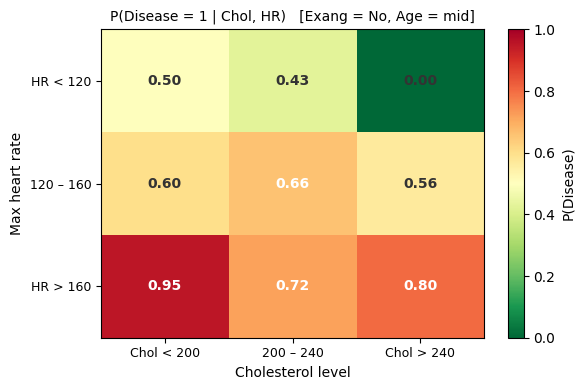

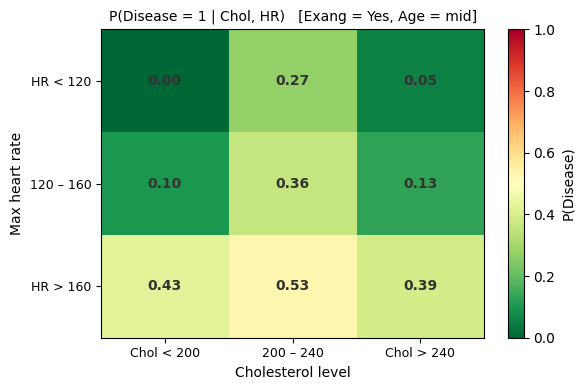

In [15]:
def posterior_heatmap(I, fix_exang=0, fix_age=1):
    grid     = np.zeros((3, 3))
    labels_c = ["Chol < 200", "200 – 240", "Chol > 240"]
    labels_h = ["HR < 120",   "120 – 160", "HR > 160"]

    for c in range(3):
        for h in range(3):
            ev  = {1: c, 4: h, 2: fix_exang, 3: fix_age}
            pd  = query_disease(I, ev)
            grid[h, c] = pd["val"][1]

    fig, ax = plt.subplots(figsize=(6, 4))
    im = ax.imshow(grid, cmap="RdYlGn_r", vmin=0, vmax=1, aspect="auto")
    ax.set_xticks(range(3));   ax.set_xticklabels(labels_c, fontsize=9)
    ax.set_yticks(range(3));   ax.set_yticklabels(labels_h, fontsize=9)
    ax.set_xlabel("Cholesterol level")
    ax.set_ylabel("Max heart rate")
    exang_label = "Yes" if fix_exang else "No"
    ax.set_title(
        f"P(Disease = 1 | Chol, HR)   [Exang = {exang_label}, Age = mid]",
        fontsize=10
    )
    for i in range(3):
        for j in range(3):
            ax.text(j, i, f"{grid[i,j]:.2f}", ha="center", va="center",
                    fontsize=10, fontweight="bold",
                    color="white" if grid[i, j] > 0.6 else "#333")
    plt.colorbar(im, ax=ax, label="P(Disease)")
    plt.tight_layout()
    plt.show()

# Exang = No
posterior_heatmap(I, fix_exang=0)

# Exang = Yes
posterior_heatmap(I, fix_exang=1)

**Observations:**

- Without exercise-induced angina, disease probability increases substantially with higher heart rate — particularly in the HR > 160 band, where probabilities reach 0.72–0.95 regardless of cholesterol level.
- With exercise-induced angina present, the pattern partially reverses: disease probability is markedly lower across all cholesterol–HR combinations. This counter-intuitive result may reflect a data artefact or a confound in the dataset (patients with angina may have been triaged differently), and warrants caution in clinical interpretation.
- The network correctly captures the non-linear interaction of risk factors, producing heterogeneous risk profiles across the 3×3 grid rather than monotone trends.


---

## 10. Summary

| Quantity | Value |
|----------|-------|
| MEU (unconditional) | 30.35 |
| Unconditional optimal decision | Test |
| MEU (given high-risk evidence profile) | 0.04 |
| Conditional optimal decision | No Test |
| EVPI | 14.90 |

The analysis demonstrates that Bayesian Decision Networks provide a principled framework for integrating probabilistic beliefs with explicit utility structures. The key finding is that the optimal action is **not fixed**: it depends critically on the observed patient evidence. The population-level prior favours testing, but specific clinical profiles can shift the posterior sufficiently to reverse that recommendation. The EVPI of 14.9 further anchors the economic interpretation of this decision problem.
